# Day 08. Exercise 04
# Regression

## 0. Imports

In [6]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd

## 1. Preprocessing

1. Read the file [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Fill the missing values in it with `0`.
3. Make a split of your dataset on train and test with parameters `test_size=0.2`.

In [7]:
df = pd.read_csv('../data/checker_regression.csv')
df = df.fillna(0)
df = df.groupby('uid').mean().reset_index()
df = df.drop(columns=['uid'])
X = df.drop('AVG(diff)', axis=1)
y = df['AVG(diff)']
df['num_commits'] = df['num_commits'].astype('int64')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   num_commits  29 non-null     int64  
 1   pageviews    29 non-null     float64
 2   AVG(diff)    29 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 824.0 bytes


## 2. Crossvalidation

1. Write a function `crossval` that takes as arguments: `n_splits` for `KFold()`, `X`, `y`, model instantiated class with the parameters of the model (keep in mind: `random_state=21`) and returns for a given model class a result like this:

```
train -  2696.4496895424836   |   test -  1589.9979527104958
train -  2660.957874001452   |   test -  2075.102636027137
train -  2847.315529246795   |   test -  320.911928168403
train -  2500.7691099659237   |   test -  4132.461382030178
train -  2643.927917295123   |   test -  2237.8140952197878
train -  2396.295678819444   |   test -  4509.650064742476
train -  2003.402267924976   |   test -  8403.491474908551
train -  2531.876094212613   |   test -  3135.944102735099
train -  2683.1795186023123   |   test -  1796.01426292594
train -  2537.1192483996338   |   test -  3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Run the function for `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. You may choose the parameters by yourself, but find the good enough for you.

In [ ]:
def crossval(n_splits, X, y, model):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=21)
    train_scores = []
    test_scores = []
    
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        model.fit(X_train, y_train)
        
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
        test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)
        
        train_scores.append(train_rmse)
        test_scores.append(test_rmse)
        
        print(f"train -  {train_rmse}   |   test -  {test_rmse}")
    
    print(f"Average RMSE on crossval is {np.mean(test_scores)}")

print("\nLinearRegression:")
crossval(10, X, y, LinearRegression())

print("\nDecisionTreeRegressor:")
crossval(10, X, y, DecisionTreeRegressor(random_state=21, max_depth=6))

print("\nRandomForestRegressor:")
crossval(10, X, y, RandomForestRegressor(random_state=21, n_estimators=100, max_depth=10))


LinearRegression:
<generator object _BaseKFold.split at 0x7fcd300ce850>
train -  61.35327112662008   |   test -  57.85614740884658
train -  62.5462335194863   |   test -  44.71218893425673
train -  61.14556371253599   |   test -  83.19897138394582
train -  58.416728626194235   |   test -  79.399015977114
train -  60.11026827841826   |   test -  68.756146189296
train -  60.61932302839533   |   test -  65.92296908962915
train -  61.72075104991357   |   test -  61.800360553015715
train -  62.60680682836641   |   test -  46.68994292992783
train -  55.58034321272078   |   test -  99.08124434288634
train -  61.577932451061805   |   test -  53.24118830442656
Average RMSE on crossval is 66.06581751133447

DecisionTreeRegressor:
<generator object _BaseKFold.split at 0x7fcd300ce950>
train -  0.0   |   test -  117.17718934888181
train -  0.0   |   test -  79.5333147061541
train -  10.822768023583787   |   test -  0.0
train -  10.822768023583787   |   test -  78.98656472722058
train -  0.0   |   

## 3. Predictions and evaluation

1. Make predictions for the test dataset using each of the three models with the finalized parameters.
2. Draw a plot for each of the models where the `x-axis` is the actual average difference and the `y-axis` is the prediction made by a model.
3. How would plot look like in the ideal case? Put the answer to the markdown cell in the end of the section.

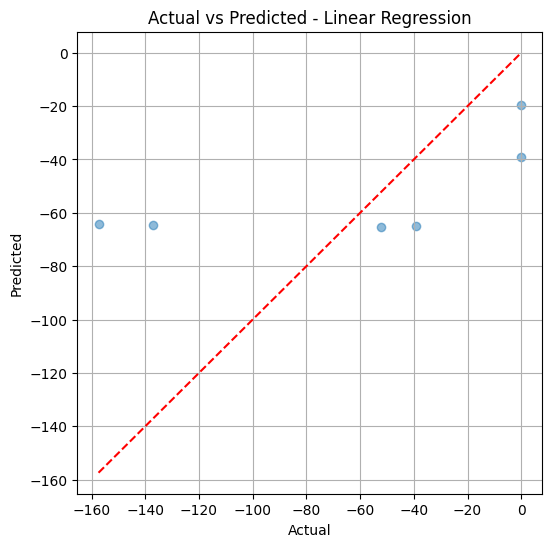

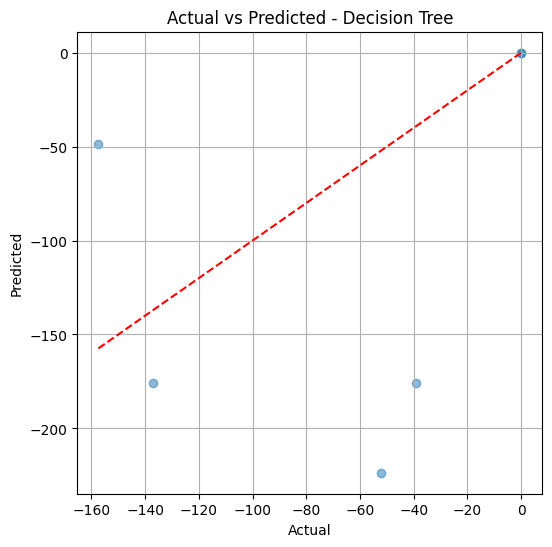

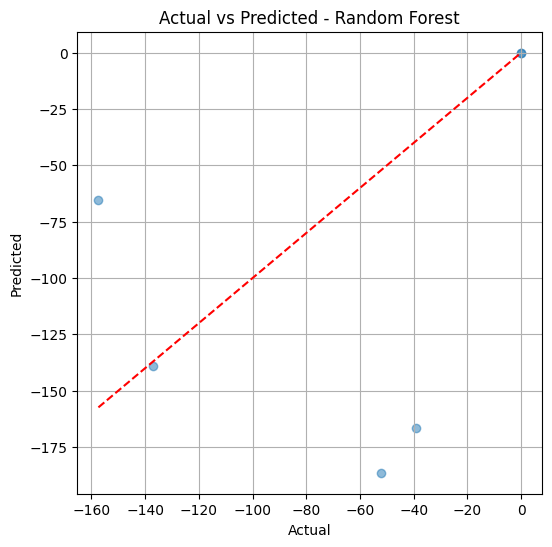

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=21),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=25, random_state=21)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, preds, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'Actual vs Predicted - {name}')
    plt.grid(True)
    plt.show()

все точки будут лежать прямо на диагонали